# 04. Predictive Modeling, Evaluation & Explainability
## Banking Customer Churn Analytics

### Objectives
1. Train and benchmark candidate algorithms with 5-Fold Stratified Cross-Validation:
   - **Logistic Regression** (L2 regularized baseline)
   - **Random Forest Classifier**
   - **HistGradientBoosting Classifier**
2. Fine-tune champion hyperparameters using `GridSearchCV`.
3. Evaluate holdout test performance (ROC-AUC, PR-AUC, Confusion Matrix, Decision Threshold Tuning).
4. Perform Permutation Feature Importance for Explainable AI (XAI).


In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.abspath(".."))
from src.feature_engineering import BankFeatureEngineer
from src.modeling import BankChurnModeler
from src.evaluation import BankChurnEvaluator

sns.set_theme(style="whitegrid")
df = pd.read_csv("../data/processed/bank_customer_churn_clean.csv")
fe = BankFeatureEngineer()
X_train, X_test, y_train, y_test, feat_cols = fe.prepare_train_test_data(df)


## 1. Candidate Algorithm Cross-Validation Benchmark

In [2]:
modeler = BankChurnModeler(random_state=42)
cv_results = modeler.train_and_cross_validate(X_train, y_train, n_splits=5)

benchmark_df = pd.DataFrame(cv_results).T
benchmark_df[["roc_auc_mean", "roc_auc_std", "pr_auc_mean", "f1_mean", "recall_mean", "accuracy_mean"]].round(4)


[Modeler] Running 5-Fold Stratified Cross-Validation on 3 candidate models...


  [OK] Logistic Regression    | ROC-AUC: 0.8483 (+/-0.0129) | PR-AUC: 0.6561 | F1: 0.5828


  [OK] Random Forest          | ROC-AUC: 0.8544 (+/-0.0101) | PR-AUC: 0.6700 | F1: 0.6119


  [OK] Gradient Boosting      | ROC-AUC: 0.8530 (+/-0.0125) | PR-AUC: 0.6851 | F1: 0.6106
[Modeler] Champion model selected: 'Random Forest' (ROC-AUC: 0.8544)


,roc_auc_mean,roc_auc_std,pr_auc_mean,f1_mean,recall_mean,accuracy_mean
Logistic Regression,0.8483,0.0129,0.6561,0.5828,0.7399,0.7844
Random Forest,0.8544,0.0101,0.6700,0.6119,0.6712,0.8270
Gradient Boosting,0.8530,0.0125,0.6851,0.6106,0.6779,0.8241


## 2. Hyperparameter Fine-Tuning

In [3]:
champion_model = modeler.tune_champion_hyperparameters(X_train, y_train)


[Modeler] Fine-tuning champion Gradient Boosting model with GridSearchCV...


[Modeler] Best Hyperparameters: {'classifier__l2_regularization': 1.0, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 5, 'classifier__max_iter': 150, 'classifier__min_samples_leaf': 25}
[Modeler] Best CV ROC-AUC: 0.8603


## 3. Holdout Test Set Evaluation & ROC / PR Curves

In [4]:
evaluator = BankChurnEvaluator()
y_probs = champion_model.predict_proba(X_test)[:, 1]

test_metrics = evaluator.evaluate_predictions(y_test, y_probs)
print(f"Test Set ROC-AUC: {test_metrics['roc_auc']:.4f}")
print(f"Test Set PR-AUC:  {test_metrics['pr_auc']:.4f}")
print(f"Test Set F1:      {test_metrics['f1_score']:.4f}")
print(f"Test Set Recall:  {test_metrics['recall']:.4f}")
print(f"Test Set Precision: {test_metrics['precision']:.4f}")


Test Set ROC-AUC: 0.8661
Test Set PR-AUC:  0.7160
Test Set F1:      0.6163
Test Set Recall:  0.7518
Test Set Precision: 0.5222


## 4. Decision Threshold Optimization for Business Profit

Optimal Business Decision Threshold: 0.23


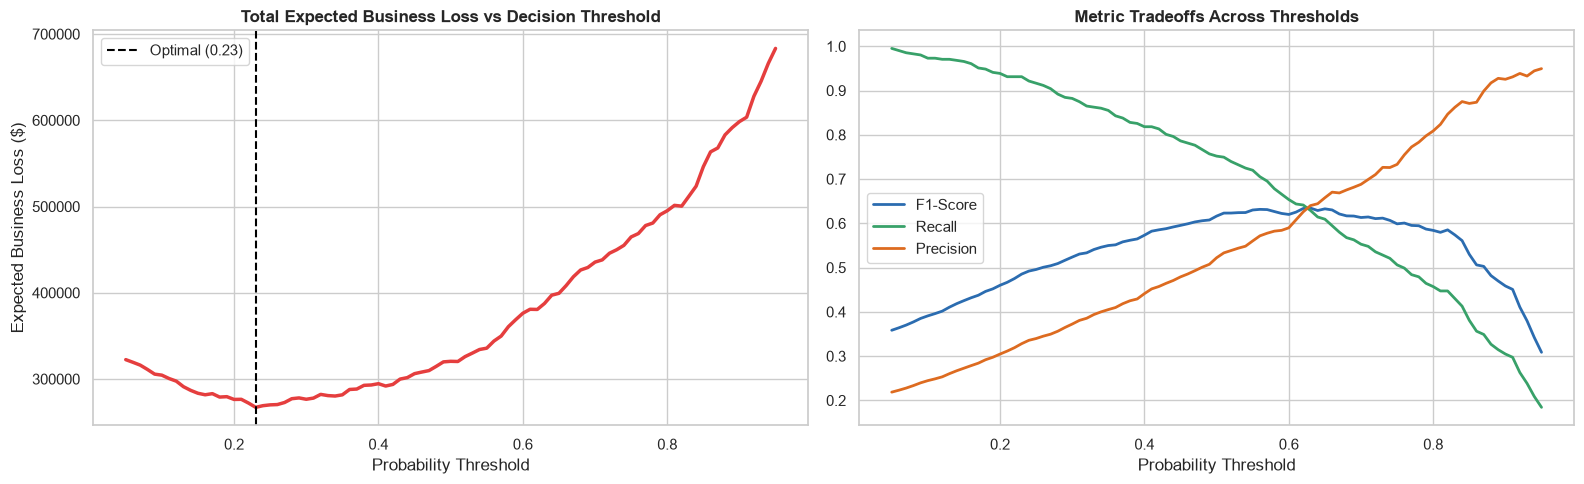

In [5]:
opt_thresh, thresh_df = evaluator.optimize_decision_threshold(
    y_test, y_probs,
    cost_false_negative=2000.0,
    cost_false_positive=150.0,
    cost_true_positive=250.0
)

print(f"Optimal Business Decision Threshold: {opt_thresh:.2f}")

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
ax[0].plot(thresh_df["threshold"], thresh_df["business_loss"], color="#E53E3E", lw=2.5)
ax[0].axvline(opt_thresh, color="black", linestyle="--", label=f"Optimal ({opt_thresh:.2f})")
ax[0].set_title("Total Expected Business Loss vs Decision Threshold", fontweight="bold")
ax[0].set_xlabel("Probability Threshold")
ax[0].set_ylabel("Expected Business Loss ($)")
ax[0].legend()

ax[1].plot(thresh_df["threshold"], thresh_df["f1_score"], label="F1-Score", color="#2B6CB0", lw=2)
ax[1].plot(thresh_df["threshold"], thresh_df["recall"], label="Recall", color="#38A169", lw=2)
ax[1].plot(thresh_df["threshold"], thresh_df["precision"], label="Precision", color="#DD6B20", lw=2)
ax[1].set_title("Metric Tradeoffs Across Thresholds", fontweight="bold")
ax[1].set_xlabel("Probability Threshold")
ax[1].legend()
plt.tight_layout()
plt.show()


## 5. Permutation Feature Importance (Explainable AI - XAI)

[Evaluator] Computing Permutation Feature Importances on test set...


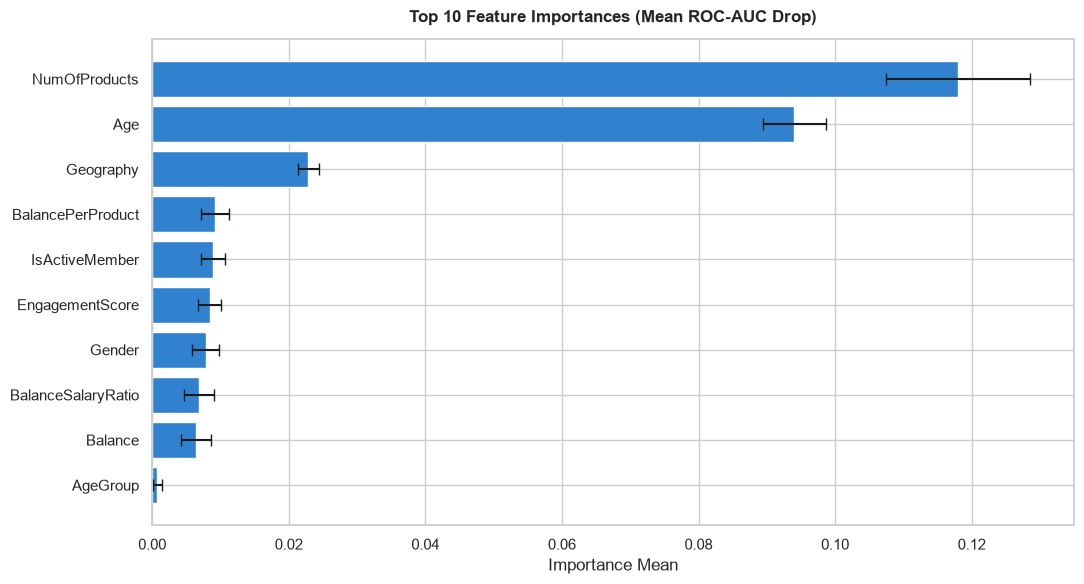

In [6]:
importance_df = evaluator.compute_permutation_importances(champion_model, X_test, y_test)

plt.figure(figsize=(11, 6))
top_10 = importance_df.head(10).sort_values(by="Importance_Mean", ascending=True)
plt.barh(top_10["Feature"], top_10["Importance_Mean"], xerr=top_10["Importance_Std"], color="#3182CE", capsize=4)
plt.title("Top 10 Feature Importances (Mean ROC-AUC Drop)", fontweight="bold", pad=12)
plt.xlabel("Importance Mean")
plt.tight_layout()
plt.show()
